In [1]:
# =====================================
# CUSTOMER CHURN PREDICTION (COLAB FINAL)
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io # Added this import

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# =====================================
# Load Dataset
# =====================================

# Read the entire file content as a single string
with open("churn_data.csv", "r") as f:
    file_content = f.read()

# The 'uploaded' variable in the kernel state shows the content starting with " and ending with "\n"
# If file_content is like '"col1,col2\nval1,val2\n"', then file_content[0] is '"' and file_content[-1] is '\n'
# We need to remove the first char (") and the last two chars ("\n") IF the entire content is wrapped.
if file_content.startswith('"') and file_content.endswith('"\n'):
    # This removes the very first " and the very last "\n"
    content_stripped_outermost = file_content[1:-2]
else:
    content_stripped_outermost = file_content

# The content_stripped_outermost might still have each logical line wrapped in quotes,
# e.g., 'header,col2"\n"data1,data2"\n"data3,data4'
# We need to strip these line-level quotes to get a clean CSV string for pandas.
lines = content_stripped_outermost.splitlines()
processed_lines = []
for line in lines:
    if line.startswith('"') and line.endswith('"'):
        processed_lines.append(line[1:-1]) # Remove quotes from both ends
    elif line.startswith('"'): # Handles lines starting with quote but not ending with one
        processed_lines.append(line[1:])
    elif line.endswith('"'): # Handles lines ending with quote but not starting with one
        processed_lines.append(line[:-1])
    else:
        processed_lines.append(line)

cleaned_content = "\n".join(processed_lines)

# Read the cleaned content as a CSV using io.StringIO
df = pd.read_csv(io.StringIO(cleaned_content))

print("Columns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Contract', 'PaymentMethod', 'Churn'],
      dtype='str')

First 5 rows:
   customerID  gender  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  \
0       C001    Male              0       1           29.85         29.85   
1       C002  Female              0      34           56.95       1889.50   
2       C003  Female              0       2           53.85        108.15   
3       C004    Male              0      45           42.30       1840.75   
4       C005    Male              0       2           70.70        151.65   

         Contract     PaymentMethod Churn  
0  Month-to-month  Electronic check   Yes  
1        One year      Mailed check    No  
2  Month-to-month      Mailed check   Yes  
3        One year     Bank transfer    No  
4  Month-to-month  Electronic check   Yes  


In [3]:
# =====================================
# Data Cleaning
# =====================================

df.drop(columns=["customerID"], errors='ignore', inplace=True)

if "TotalCharges" in df.columns:
    # Corrected chained assignment warning: Directly assign the result
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# =====================================
# Encoding
# =====================================

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df = pd.get_dummies(df, drop_first=True)


In [4]:
# =====================================
# Split Data
# =====================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# Model Training
# =====================================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# =====================================
# Evaluation
# =====================================

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("\nLogistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Logistic Accuracy: 1.0
Random Forest Accuracy: 1.0


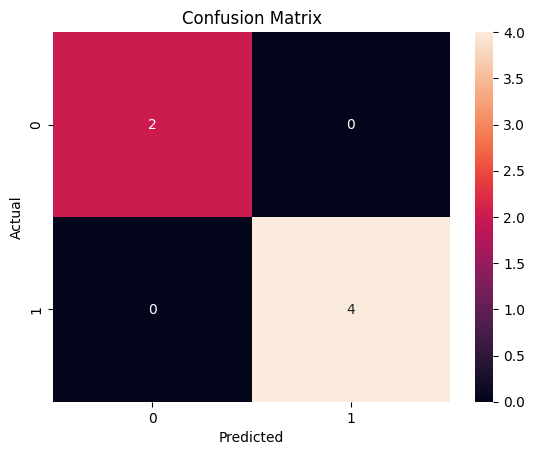

In [6]:
# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

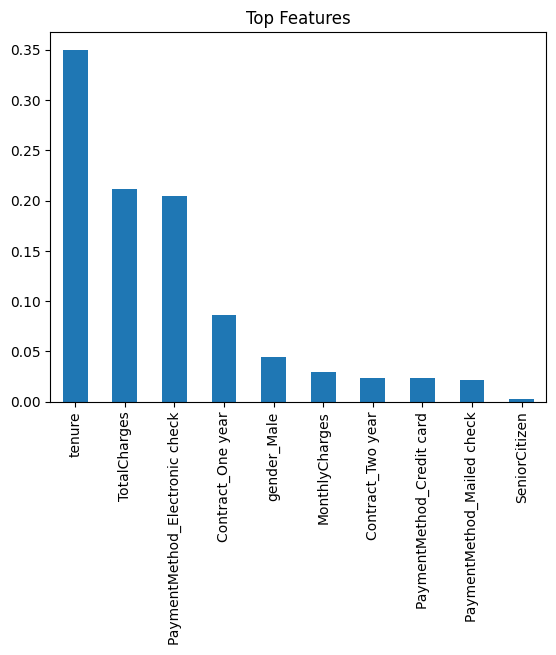

In [7]:
# =====================================
# Feature Importance
# =====================================

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [8]:
# =====================================
# Prediction
# =====================================

sample = X_test.iloc[0].values
prediction = rf.predict([sample])

print("\nSample Prediction:", "Churn" if prediction[0] == 1 else "No Churn")


Sample Prediction: Churn


c:\Programs\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
